# RecruTap - Model Training

## Objective

This notebook trains and evaluates machine learning models capable of classifying job postings as genuine or fraudulent.

The objectives are:

- Load the processed dataset
- Convert text into numerical features using TF-IDF
- Split the data into training and testing sets
- Train multiple classification models
- Evaluate model performance
- Save the best-performing model for deployment

## Import Required Libraries

Import the machine learning libraries required for vectorization, model training, evaluation and model serialization.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import MultinomialNB

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)

import joblib

## Load Processed Dataset

Load the feature-engineered dataset generated in the previous notebook.

In [2]:
df = pd.read_csv("../data/processed/model_dataset.csv")

df.head()

,clean_text,fraudulent
0,marketing intern food weve created groundbreak...,0
1,customer service cloud video production second...,0
2,commissioning machinery assistant cma valor se...,0
3,account executive washington dc passion improv...,0
4,review manager spotsource solutions llc global...,0


## Define Features and Target

- Feature (X): Cleaned job posting text
- Target (y): Fraudulent label

In [3]:
X = df["clean_text"]

y = df["fraudulent"]

## TF-IDF Vectorization

Transform textual information into numerical vectors.

TF-IDF assigns greater importance to words that are informative while reducing the influence of common words.

In [ ]:
vectorizer = TfidfVectorizer(max_features=10000)

X_vectorized = vectorizer.fit_transform(X)

## Train-Test Split

The dataset is divided into:

- 80% Training
- 20% Testing

Stratified sampling preserves the class distribution across both datasets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42, stratify=y)

## Model Comparison

Three machine learning algorithms are evaluated:

- Logistic Regression
- Multinomial Naive Bayes
- Random Forest

The best-performing model will be selected for deployment.

### 1. Logistic Regression

In [7]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

Accuracy: 0.9748322147651006
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3403
           1       1.00      0.48      0.65       173

    accuracy                           0.97      3576
   macro avg       0.99      0.74      0.82      3576
weighted avg       0.98      0.97      0.97      3576



### 2. Naive Bayes

In [8]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, nb_pred))

print(classification_report(y_test, nb_pred))

Accuracy: 0.962248322147651
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3403
           1       0.88      0.25      0.39       173

    accuracy                           0.96      3576
   macro avg       0.92      0.63      0.69      3576
weighted avg       0.96      0.96      0.95      3576



### 3. Random Forest

In [ ]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Accuracy: 0.9832214765100671
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       0.99      0.66      0.79       173

    accuracy                           0.98      3576
   macro avg       0.99      0.83      0.89      3576
weighted avg       0.98      0.98      0.98      3576



In [10]:
cm = confusion_matrix(y_test, lr_pred)

cm

array([[3403,    0],
       [  90,   83]], dtype=int64)

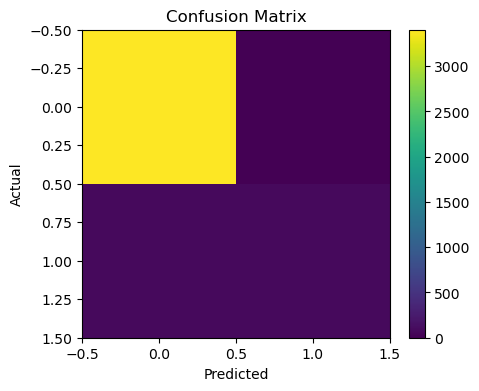

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

plt.imshow(cm)

plt.colorbar()

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Save Trained Model

The trained classifier and TF-IDF vectorizer are serialized using Joblib.

These files will later be loaded by the FastAPI backend to perform real-time fraud prediction.

In [ ]:
joblib.dump(lr, "../models/fraud_detector.pkl")

['../models/fraud_detector.pkl']

In [ ]:
joblib.dump(vectorizer,"../models/tfidf_vectorizer.pkl")

['../models/tfidf_vectorizer.pkl']

# Conclusion

Three classification models were trained and evaluated.

The best-performing model was selected based on predictive performance and exported for deployment.

The saved model and TF-IDF vectorizer will be integrated into the RecruTap backend during the inference stage.